In [1]:
import sys
sys.path.append("..")

import config
from src.loader import load_reviews, load_meta
from src import preprocessing, analysis, plots, storage

In [2]:
df = storage.load_stage("reviews_clean")

In [3]:
analysis.data_quality(df)

--- Missing values ---
rating               0
title                0
text                 0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
text_len             0
title_len            0
dtype: int64

Empty strings (text): 0
Empty strings (title): 0

Duplicates (user_id + asin): 0
Duplicates (full row): 0

Date range: 2003-03-06 → 2023-03-16
Unique products (asin): 4671
Unique users: 763
Verified purchase: {True: 3348, False: 1650}

--- Rating distribution ---
rating
1.0     395
2.0     196
3.0     326
4.0     812
5.0    3269
Name: count, dtype: int64


In [4]:
plots.rating_histogram(df).show()

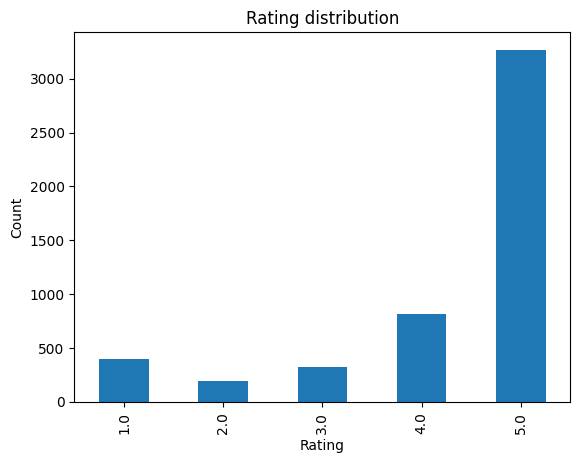

In [5]:
fig = plots.rating_histogram_mpl(df)

In [6]:
plots.text_length_histogram(df).show()

In [7]:
plots.reviews_over_time(df).show()

## Opinions over time and review length

Rating trend over time, review-length distribution per rating, helpful votes vs length, seasonality, and the long tail of reviews per product.

In [8]:
plots.rating_over_time(df).show()

In [9]:
plots.text_length_by_rating(df).show()

In [10]:
plots.helpful_vs_length(df).show()

In [11]:
plots.seasonality_heatmap(df).show()

In [12]:
plots.reviews_per_product(df).show()

## Products and categories (metadata)

Join reviews with product metadata, then explore category structure (treemap), price vs average rating, and ratings per category.

In [13]:
meta = storage.load_stage("meta_clean")
merged = preprocessing.merge_meta(df, meta)
print("Meta shape:", meta.shape, "| Merged shape:", merged.shape)

Merging reviews with product metadata on parent_asin
Meta shape: (5000, 18) | Merged shape: (4998, 18)


In [14]:
plots.category_treemap(meta).show()

In [15]:
plots.price_vs_rating(meta).show()

In [16]:
analysis.category_summary(merged)

--- Reviews by main_category ---
                           n_reviews  avg_rating
main_category                                   
Computers                         11    4.818182
All Electronics                   10    4.400000
Amazon Devices                     6    4.333333
Cell Phones & Accessories          6    4.166667
Camera & Photo                     2    3.000000
Home Audio & Theater               2    5.000000
Amazon Home                        1    5.000000
Apple Products                     1    5.000000
Industrial & Scientific            1    4.000000

--- Average rating by price bucket ---
price
(6.598999999999999, 11.965]    4.857143
(11.965, 16.99]                4.625000
(16.99, 25.49]                 4.428571
(25.49, 258.99]                3.500000
Name: rating, dtype: float64
